In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
file_path="/content/drive/MyDrive/healthcare_dataset.csv"

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv(file_path)
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [6]:
print(df.shape)

(55500, 15)


In [7]:
print(df.columns.tolist())

['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition', 'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider', 'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date', 'Medication', 'Test Results']


In [8]:
df['Date of Admission'] = pd.to_datetime(
    df['Date of Admission'],
    errors='coerce'
)

df['Discharge Date'] = pd.to_datetime(
    df['Discharge Date'],
    errors='coerce'
)

df['Stay_Days'] = (
    df['Discharge Date'] - df['Date of Admission']
).dt.days

display(df[['Date of Admission', 'Discharge Date', 'Stay_Days']].head())

,Date of Admission,Discharge Date,Stay_Days
0,2024-01-31,2024-02-02,2
1,2019-08-20,2019-08-26,6
2,2022-09-22,2022-10-07,15
3,2020-11-18,2020-12-18,30
4,2022-09-19,2022-10-09,20


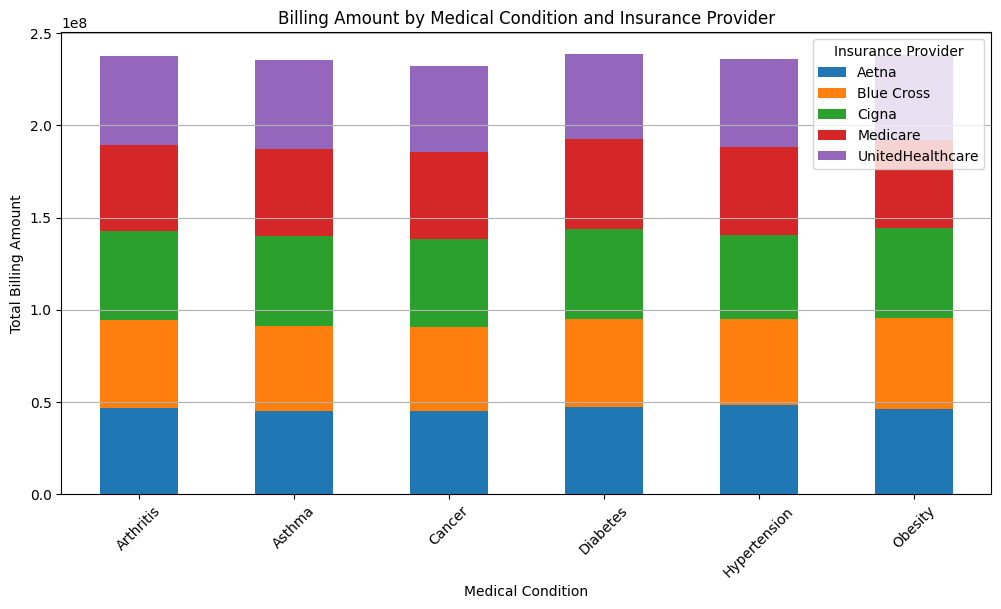

In [9]:
billing_stack = pd.pivot_table(
    df,
    values='Billing Amount',
    index='Medical Condition',
    columns='Insurance Provider',
    aggfunc='sum',
    fill_value=0
)

billing_stack.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6)
)

plt.title('Billing Amount by Medical Condition and Insurance Provider')
plt.xlabel('Medical Condition')
plt.ylabel('Total Billing Amount')

plt.xticks(rotation=45)
plt.legend(title='Insurance Provider')
plt.grid(axis='y')

plt.show()

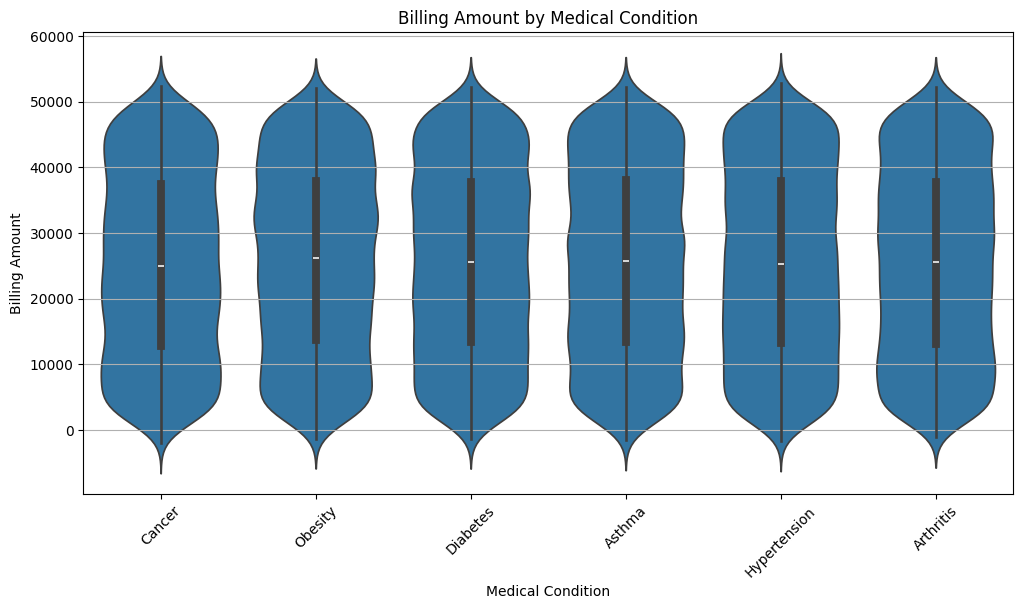

In [11]:
plt.figure(figsize=(12, 6))

sns.violinplot(
    data=df,
    x='Medical Condition',
    y='Billing Amount'
)

plt.title('Billing Amount by Medical Condition')
plt.xlabel('Medical Condition')
plt.ylabel('Billing Amount')

plt.xticks(rotation=45)

plt.grid(axis='y')

plt.show()

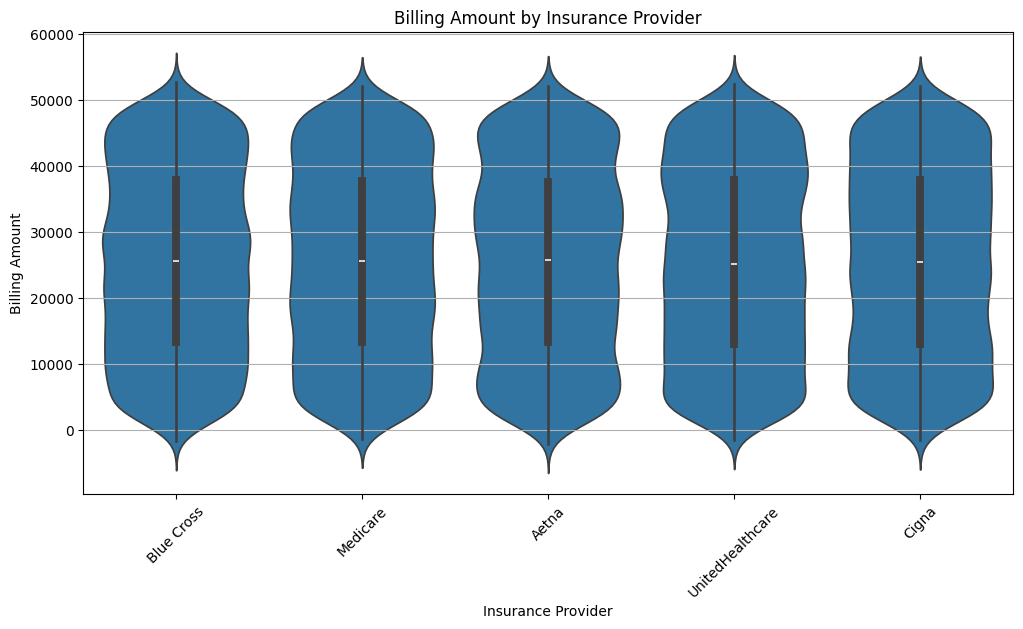

In [12]:
plt.figure(figsize=(12, 6))

sns.violinplot(
    data=df,
    x='Insurance Provider',
    y='Billing Amount'
)

plt.title('Billing Amount by Insurance Provider')
plt.xlabel('Insurance Provider')
plt.ylabel('Billing Amount')

plt.xticks(rotation=45)

plt.grid(axis='y')

plt.show()

In [13]:
df['Date of Admission'] = pd.to_datetime(
    df['Date of Admission'],
    errors='coerce'
)

print(df['Date of Admission'].head())

0   2024-01-31
1   2019-08-20
2   2022-09-22
3   2020-11-18
4   2022-09-19
Name: Date of Admission, dtype: datetime64[ns]


In [14]:
monthly_admissions = (
    df.groupby(
        df['Date of Admission'].dt.to_period('M')
    )
    .size()
)

print(monthly_admissions)

Date of Admission
2019-05     686
2019-06     907
2019-07     957
2019-08    1001
2019-09     936
           ... 
2024-01     909
2024-02     880
2024-03     906
2024-04     946
2024-05     213
Freq: M, Length: 61, dtype: int64


In [16]:
peak_month = monthly_admissions.idxmax()

peak_admissions = monthly_admissions.max()

print("Peak Admission Month:", peak_month)
print("Number of Admissions:", peak_admissions)

Peak Admission Month: 2020-08
Number of Admissions: 1014


In [17]:
correlation_data = df[
    ['Age', 'Stay_Days', 'Billing Amount']
]

correlation_matrix = correlation_data.corr()

print(correlation_matrix)

                     Age  Stay_Days  Billing Amount
Age             1.000000   0.008220       -0.003832
Stay_Days       0.008220   1.000000       -0.005602
Billing Amount -0.003832  -0.005602        1.000000


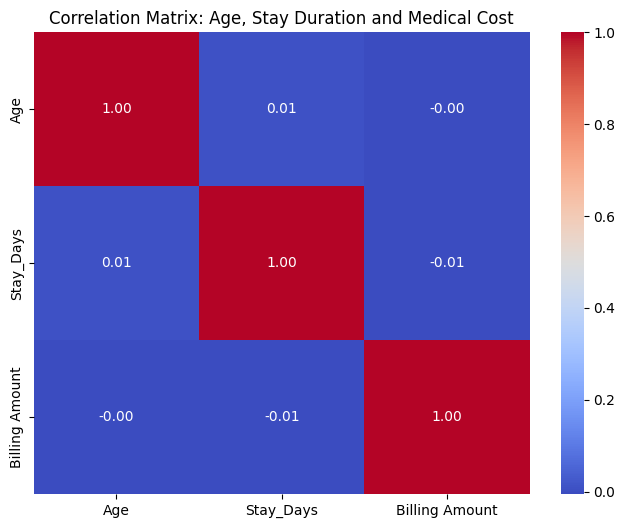

In [18]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title(
    'Correlation Matrix: Age, Stay Duration and Medical Cost'
)

plt.show()

In [19]:
avg_billing_condition = df.groupby(
    'Medical Condition'
)['Billing Amount'].mean()

print(avg_billing_condition)

Medical Condition
Arthritis       25497.327056
Asthma          25635.249359
Cancer          25161.792707
Diabetes        25638.405577
Hypertension    25497.095761
Obesity         25805.971259
Name: Billing Amount, dtype: float64


In [20]:
avg_billing_insurance = df.groupby(
    'Insurance Provider'
)['Billing Amount'].mean()

print(avg_billing_insurance)

Insurance Provider
Aetna               25553.294506
Blue Cross          25613.011503
Cigna               25525.766314
Medicare            25615.990508
UnitedHealthcare    25389.172390
Name: Billing Amount, dtype: float64


In [21]:
print("========== HEALTHCARE EXECUTIVE SUMMARY ==========")

print("\nTotal Patients:", len(df))

print(
    "Average Billing Amount:",
    round(df['Billing Amount'].mean(), 2)
)

print(
    "Average Hospital Stay:",
    round(df['Stay_Days'].mean(), 2),
    "days"
)

print(
    "Average Patient Age:",
    round(df['Age'].mean(), 2)
)

print(
    "\nMost Common Medical Condition:",
    df['Medical Condition'].mode()[0]
)

print(
    "Most Common Insurance Provider:",
    df['Insurance Provider'].mode()[0]
)

print(
    "\nPeak Admission Month:",
    peak_month
)

print(
    "Peak Admissions:",
    peak_admissions
)

========== HEALTHCARE EXECUTIVE SUMMARY ==========

Total Patients: 55500
Average Billing Amount: 25539.32
Average Hospital Stay: 15.51 days
Average Patient Age: 51.54

Most Common Medical Condition: Arthritis
Most Common Insurance Provider: Cigna

Peak Admission Month: 2020-08
Peak Admissions: 1014


In [23]:
print("Final Dataset:")

display(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

Final Dataset:


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Stay_Days
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal,2
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,6
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal,15
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal,30
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal,20



Dataset Shape:
(55500, 16)

Missing Values:
Name                  0
Age                   0
Gender                0
Blood Type            0
Medical Condition     0
Date of Admission     0
Doctor                0
Hospital              0
Insurance Provider    0
Billing Amount        0
Room Number           0
Admission Type        0
Discharge Date        0
Medication            0
Test Results          0
Stay_Days             0
dtype: int64
